# **PROJECT TITLE: CUSTOMER CHURN PREDICTION**
![Customer_Churn](Images/Customer_Churn.png)

In [22]:
# Import Libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay   
)

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

# **1.DATA LOADNG AND EXPLORATION**
Here the dataset was loaded and the rows and columns were explored. 


In [2]:
# Loading the dataset
df = pd.read_csv('Data/Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Checking the shape of the dataset
df.shape

(7043, 21)

In [4]:
# Checking the information of the dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
# Summary Statistics of the dataset
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [6]:
# Checking for missing values
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

There are no missing values in the dataset.

In [7]:
# Checking for duplicates
df.duplicated().sum()

np.int64(0)

There are no duplicates in the dataset.

# **2.EXPLORATORY DATA ANALYSIS (EDA)**
This step was to create visualizations.


Churn value counts:
 Churn
No     5174
Yes    1869
Name: count, dtype: int64


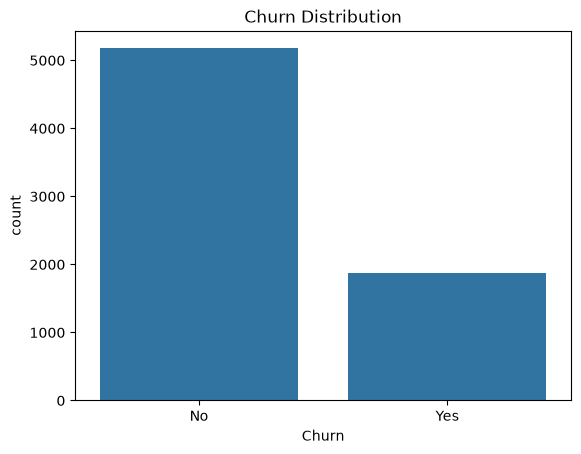

In [8]:
# Target variable distribution (assuming 'Churn' column exists)
if 'Churn' in df.columns:
    print("\nChurn value counts:\n", df['Churn'].value_counts())
    sns.countplot(x='Churn', data=df)
    plt.title("Churn Distribution")
    plt.show()

## Overview
The bar chart compares customers who **did not churn ("No")** versus those who **churned ("Yes")**:
- **No (Stayed):** ~5,000 customers
- **Yes (Churned):** ~1,900 customers

This means about **73% of customers stayed** while **27% left**.

While most customers remain loyal, churn is still high enough to warrant serious analysis.  
Identifying and addressing the drivers of churn can improve customer retention and reduce revenue loss.


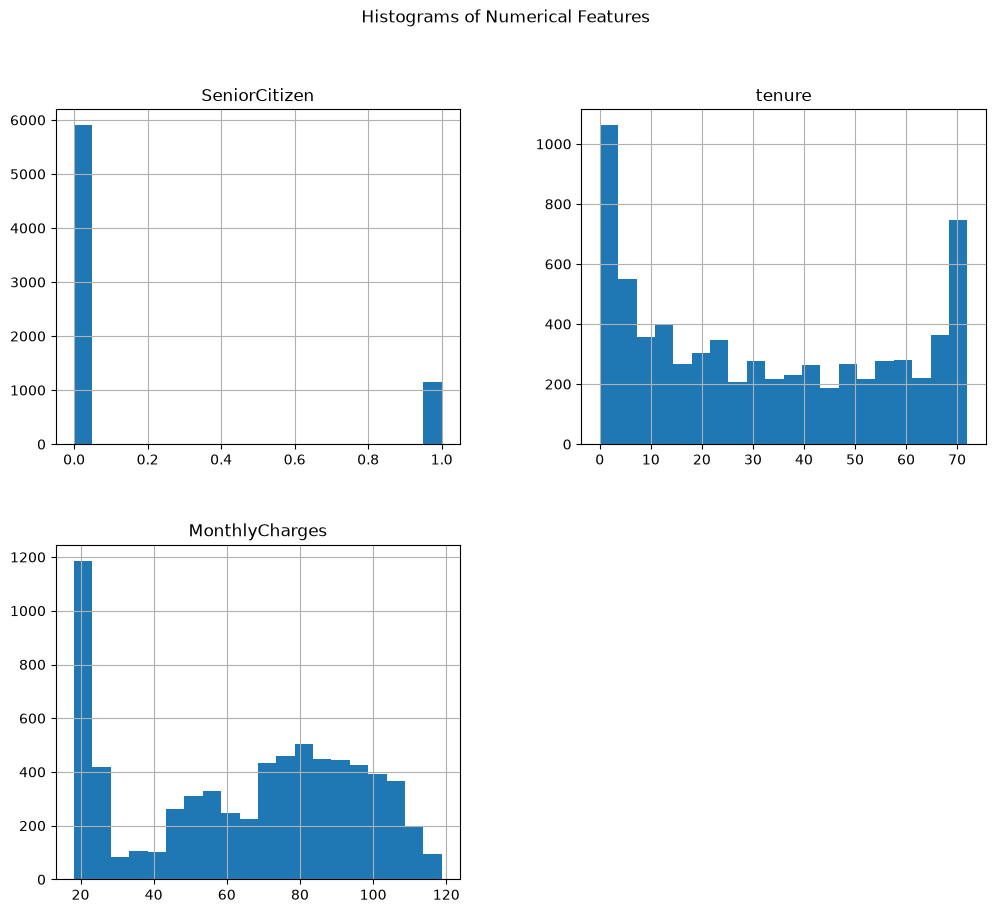

In [9]:
# Numerical features distribution
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols].hist(figsize=(12, 10), bins=20)
plt.suptitle("Histograms of Numerical Features")
plt.show()

# 📊 Interpretation of Numerical Feature Distributions

## SeniorCitizen
- This variable is binary (0 = not senior, 1 = senior).
- The histogram shows that **most customers are not senior citizens**, with only a small proportion being seniors.
- Insight: Senior status is a minority group in the dataset and may influence churn differently compared to younger customers.

## Tenure
- Tenure ranges from 0 to ~70 months.
- The distribution shows peaks near **0 months (new customers)** and **70 months (long-term customers)**.
- Insight: Many customers are either **brand new or very loyal long-term users**. Churn risk is often higher among new customers with short tenure.

## MonthlyCharges
- Monthly charges range from ~20 to 120.
- The distribution shows a large spike near **20** and a concentration around **70–90**.
- Insight: Customers are clustered into two groups — those paying **low charges** and those paying **mid-to-high charges**. Higher charges may correlate with higher churn risk.

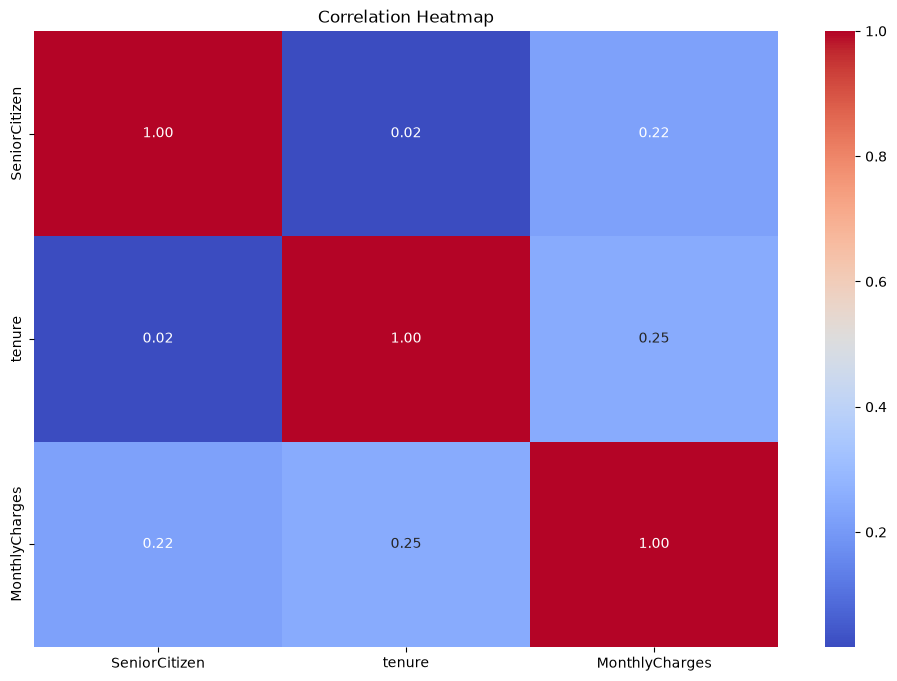

In [10]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

# 📊 Correlation Heatmap Interpretation

The heatmap shows correlations between three numerical variables:
- **SeniorCitizen**
- **tenure**
- **MonthlyCharges**


## Key Findings
- **SeniorCitizen vs Tenure: 0.02**
  - Very weak correlation.
  - Being a senior does not appear related to how long a customer has stayed.

- **SeniorCitizen vs MonthlyCharges: 0.22**
  - Weak positive correlation.
  - Senior customers tend to have slightly higher monthly charges, but the relationship is not strong.

- **Tenure vs MonthlyCharges: 0.25**
  - Weak positive correlation.
  - Customers with longer tenure tend to have somewhat higher monthly charges, but again the relationship is modest.

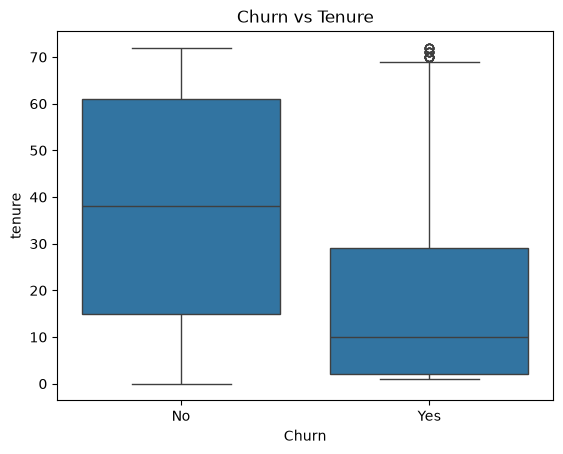

In [11]:
# Churn vs. Tenure
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title("Churn vs Tenure")
plt.show()



# 📊 Churn vs Tenure Interpretation

The box plot compares customer tenure (in months) between two groups:
- **No (Did not churn)**
- **Yes (Churned)**

## Key Findings
- **Median Tenure:**
  - Customers who did not churn have a **higher median tenure**.
  - Customers who churned have a **lower median tenure**.
- **Spread:**
  - The "No churn" group shows a wider range of tenure values, including many long-term customers.
  - The "Yes churn" group is concentrated at shorter tenures, with fewer long-term customers.
- **Outliers:**
  - Some churned customers have long tenure, but they are exceptions rather than the norm.



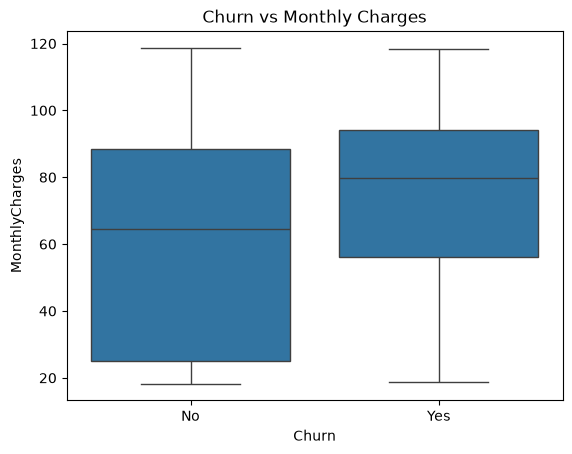

In [12]:
# Churn vs. Monthly Charges
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Churn vs Monthly Charges")
plt.show()


# 📊 Churn vs Monthly Charges Interpretation


The box plot compares monthly charges between two groups:
- **No (Did not churn)**
- **Yes (Churned)**

## Key Findings
- **Median Monthly Charges:**
  - Customers who churned have a **higher median monthly charge (~80)**.
  - Customers who did not churn have a **lower median monthly charge (~65)**.
- **Spread:**
  - The "No churn" group shows a wider range of charges, including both low and mid-level bills.
  - The "Yes churn" group is concentrated at higher charges, with fewer low-charge customers.
- **Outliers:**
  - Some non-churned customers still pay high charges, but they are exceptions.


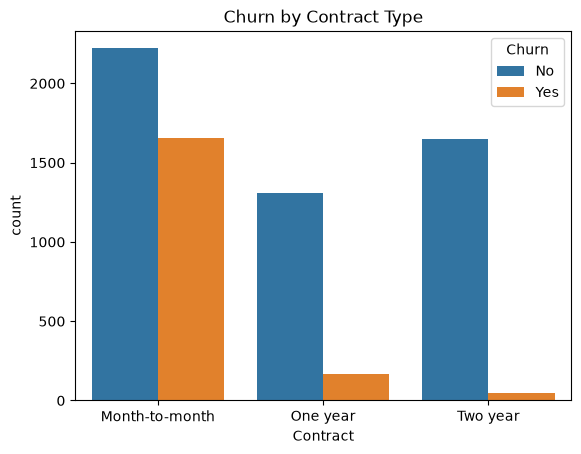

In [13]:
# Churn by Contract Type
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title("Churn by Contract Type")
plt.show()


# 📊 Churn by Contract Type Interpretation

The chart compares churn rates across three contract types:
- **Month-to-month**
- **One year**
- **Two year**

## Key Findings
- **Month-to-month contracts** show the **highest churn rate**, with many customers leaving.
- **One-year contracts** have significantly lower churn, with most customers staying.
- **Two-year contracts** show the **lowest churn rate**, indicating strong customer retention.


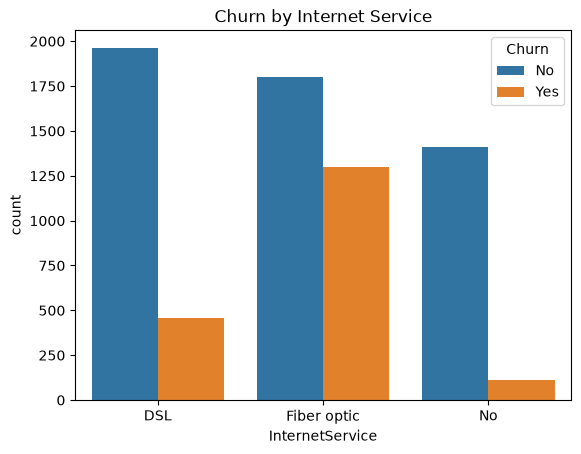

In [14]:
# Churn by Internet Service
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.title("Churn by Internet Service")
plt.show()


# 📊 Churn by Internet Service Interpretation

The chart compares churn rates across three internet service types:
- **DSL**
- **Fiber optic**
- **No internet service**

## Key Findings
- **DSL customers**: Majority did not churn, though some churn is present.
- **Fiber optic customers**: Show the **highest churn counts**, with many leaving compared to those staying.
- **No internet service customers**: Very low churn overall, with most customers staying.

# **3.FEATURE ENGINEERING**

In [66]:
# Creating Feature and Tareget
#1. Features
X = df.drop("Churn", axis=1)

# 2. Target
y = df["Churn"]

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)

print(X.shape)

print(y.shape)

(7043, 19)
(7043,)


In [67]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [68]:
# Checking Class Distribution
print(pd.Series(y_train).value_counts())

print()

print(pd.Series(y_train).value_counts(normalize=True) * 100)

0    4139
1    1495
Name: count, dtype: int64

0    73.464679
1    26.535321
Name: proportion, dtype: float64


In [69]:
# Defining Numerical and Categorical Features
numerical_features = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

categorical_features = [
    "gender",
    "Partner",
    "Dependents",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

In [70]:
# Create the processor
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

In [71]:
# Defining the models
models = {

    "Logistic Regression":
        LogisticRegression(max_iter=1000),

    "Decision Tree":
        DecisionTreeClassifier(random_state=42),

    "Random Forest":
        RandomForestClassifier(
            random_state=42,
            class_weight="balanced"
        ),

    "Gradient Boosting":
        GradientBoostingClassifier(random_state=42),

    "KNN":
        KNeighborsClassifier()

}

In [72]:
# Comparing the models
results = []

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])

    pipeline.fit(X_train, y_train)

    predictions = pipeline.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)

    results.append({
        "Model": name,
        "Accuracy": accuracy
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df

,Model,Accuracy
3,Gradient Boosting,0.806246
0,Logistic Regression,0.805536
2,Random Forest,0.767921
4,KNN,0.763662
1,Decision Tree,0.728886


# **HYPERPARAMETER TUNING**

In [73]:
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(random_state=42))
])

param_grid = {

    "classifier__n_estimators":[100,200,300],

    "classifier__learning_rate":[0.01,0.05,0.1],

    "classifier__max_depth":[3,5,7],

    "classifier__subsample":[0.8,1.0]

}

grid = GridSearchCV(

    estimator=pipeline,

    param_grid=param_grid,

    cv=5,

    scoring="f1",

    n_jobs=-1

)

grid.fit(X_train,y_train)

best_pipeline = grid.best_estimator_

print(grid.best_params_)

print(grid.best_score_)

{'classifier__learning_rate': 0.05, 'classifier__max_depth': 3, 'classifier__n_estimators': 200, 'classifier__subsample': 0.8}
0.5865151313971233


In [74]:
# Best Pipeline
best_pipeline = grid.best_estimator_

In [75]:
# Predictions
predictions = best_pipeline.predict(X_test)

probabilities = best_pipeline.predict_proba(X_test)

In [76]:
# Model Evaluation
print("Accuracy")

print(accuracy_score(
    y_test,
    predictions
))

print()

print(classification_report(
    y_test,
    predictions
))

Accuracy
0.8069552874378992

              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.67      0.53      0.59       374

    accuracy                           0.81      1409
   macro avg       0.76      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409



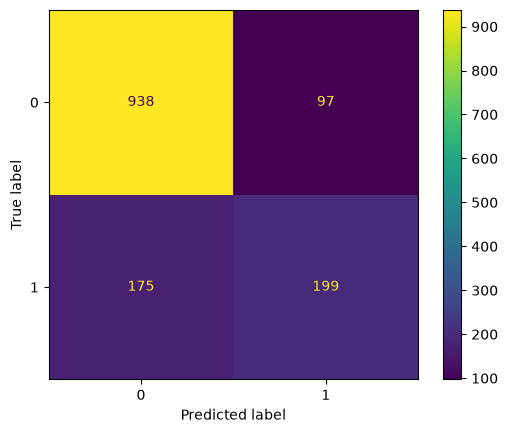

In [77]:
# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(
    best_pipeline,
    X_test,
    y_test
)

plt.show()

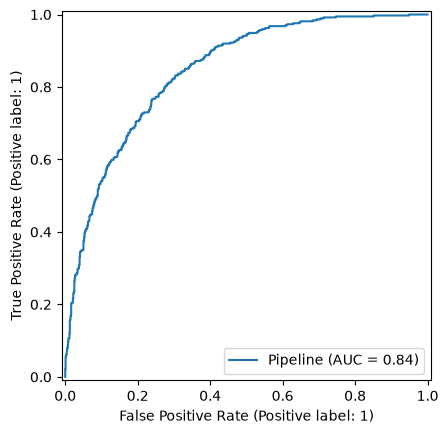

In [78]:
# ROC Curve
RocCurveDisplay.from_estimator(
    best_pipeline,
    X_test,
    y_test
)

plt.show()

In [79]:
# CRross Validation
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    best_pipeline,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print(scores)

print()

print(scores.mean())

[0.80837473 0.80979418 0.78850248 0.81321023 0.80752841]

0.8054820069036712


In [ ]:
# Saving the Pipeline

joblib.dump(
    best_pipeline,
    "churn_pipeline.pkl"
)

print("Pipeline saved successfully.")

Pipeline saved successfully.


In [ ]:
# Testing the saved Pipeline
pipeline = joblib.load("churn_pipeline.pkl")

sample = X.iloc[[0]]

prediction = pipeline.predict(sample)

probability = pipeline.predict_proba(sample)

print(prediction)

print(probability)

[1]
[[0.28082337 0.71917663]]
